In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

# Define the neural network architecture
class SimpleNN(nn.Module):
  def __init__(self):
    super().__init__()
    self.fc1 = nn.Linear(28*28, 128)
    self.relu = nn.ReLU()
    self.fc2 = nn.Linear(128, 10)

  def forward(self, x):
    x = torch.flatten(x, 1)
    x = self.fc1(x)
    x = self.relu(x)
    x = self.fc2(x)
    return x
# Load the MNIST dataset
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Instantiate the model, loss function, and optimizer
model = SimpleNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

# Train the model
num_epochs = 3
for epoch in range(num_epochs):
  running_loss = 0.0
  for inputs, labels in train_loader:
    optimizer.zero_grad()
    outputs = model(inputs)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()
    running_loss += loss.item()
  print(f"Epoch {epoch+1}, Loss: {running_loss / len(train_loader)}")

100%|██████████| 9912422/9912422 [00:00<00:00, 71989457.16it/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw



100%|██████████| 28881/28881 [00:00<00:00, 71677925.34it/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw



100%|██████████| 1648877/1648877 [00:00<00:00, 23541777.09it/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw



100%|██████████| 4542/4542 [00:00<00:00, 1058656.78it/s]


Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw

Epoch 1, Loss: 0.7522521375783725
Epoch 2, Loss: 0.3660289876178892
Epoch 3, Loss: 0.3205348068256495


In [2]:
# Evaluating the model
correct = 0
total = 0
predicted_outputs = []
with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        predicted_outputs.extend(predicted.numpy())

print(f"Accuracy on the test set: {100 * correct / total}%")

Accuracy on the test set: 91.59%


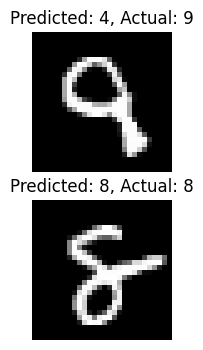

In [17]:
# Show random samples from the test set along with predicted outputs
plt.figure(figsize=(10, 4))
for i in range(2):
    index = np.random.randint(0, len(test_dataset))
    image, label = test_dataset[index]
    prediction = predicted_outputs[index]
    plt.subplot(2, 1, i+1)
    plt.imshow(image.squeeze(), cmap='gray')
    plt.title(f'Predicted: {prediction}, Actual: {label}')
    plt.axis('off')
plt.show()